In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [2]:
X_train = np.load("../data/X_train.npy")
Y_train = np.load("../data/Y_train.npy")

X_test = np.load("../data/X_test.npy")
Y_test = np.load("../data/Y_test.npy")

In [3]:
print(f"X_train: {X_train.shape}")
print(f"Y_train: {Y_train.shape}\n")

print(f"X_test: {X_test.shape}")
print(f"Y_test: {Y_test.shape}")

X_train: (1872, 60, 1)
Y_train: (1872, 1)

X_test: (484, 60, 1)
Y_test: (484, 1)


In [4]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(50, return_sequences=False))
model.add(Dense(1))

In [5]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [6]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10

59/59 [==============================] - 1s 4ms/step - loss: 0.0042
Epoch 2/10
59/59 [==============================] - 0s 4ms/step - loss: 3.8526e-04
Epoch 3/10
59/59 [==============================] - 0s 4ms/step - loss: 3.3374e-04
Epoch 4/10
59/59 [==============================] - 0s 5ms/step - loss: 2.8165e-04
Epoch 5/10
59/59 [==============================] - 0s 4ms/step - loss: 2.7126e-04
Epoch 6/10
59/59 [==============================] - 0s 6ms/step - loss: 2.3794e-04
Epoch 7/10
59/59 [==============================] - 0s 4ms/step - loss: 2.1345e-04
Epoch 8/10
59/59 [==============================] - 0s 4ms/step - loss: 1.8656e-04
Epoch 9/10
59/59 [==============================] - 0s 5ms/step - loss: 1.9205e-04
Epoch 10/10
59/59 [==============================] - 0s 4ms/step - loss: 1.7387e-04


In [9]:
model.save("../models/simplernn_best.h5", save_format="h5")

c:\Users\Zbook\Desktop\TSLA-stock-prediction\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
from tensorflow.keras.models import load_model

test_rnn = load_model("../models/simplernn_best.h5")
print("RNN loaded successfully ✅")

RNN loaded successfully ✅


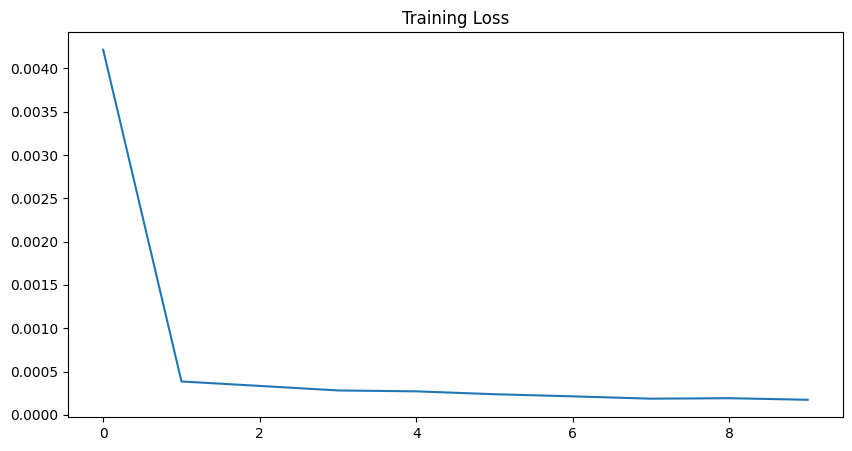

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.title("Training Loss")

plt.savefig("../outputs/plots/loss_curve.png")
plt.show()